# Retention Drivers & Root Cause Analysis

## Objective
Understand WHY employees leave by analyzing exit interviews, comparing leavers vs. stayers, and identifying key retention drivers.

## Key Questions
1. What factors correlate most strongly with attrition?
2. How do employees who leave differ from those who stay?
3. What are the primary reasons people cite for leaving?
4. Does compensation competitiveness affect retention?
5. What interventions would have the highest impact?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Load data
print("Loading data...")
employees = pd.read_csv('../data/employees.csv')
exit_interviews = pd.read_csv('../data/exit_interviews.csv')
engagement = pd.read_csv('../data/engagement_surveys.csv')

print(f"Employees: {len(employees)} records")
print(f"Exit interviews: {len(exit_interviews)} records")
print(f"Engagement surveys: {len(engagement)} records")

Loading data...
Employees: 650 records
Exit interviews: 109 records
Engagement surveys: 1191 records


## 1. Leavers vs. Stayers Comparison

In [2]:
# Separate into leavers and stayers
stayers = employees[employees['status'] == 'Active']
leavers = employees[employees['status'] == 'Terminated']

print("LEAVERS VS. STAYERS COMPARISON")
print("="*80)

# Define metrics to compare
metrics = [
    ('engagement_score', 'Engagement Score'),
    ('performance_rating', 'Performance Rating'),
    ('market_percentile', 'Market Percentile (Pay)'),
    ('months_since_promotion', 'Months Since Last Promotion'),
    ('months_since_raise', 'Months Since Last Raise'),
    ('manager_tenure_years', 'Manager Tenure (Years)'),
    ('tenure_years', 'Employee Tenure (Years)')
]

comparison_results = []

for metric_col, metric_label in metrics:
    stayers_mean = stayers[metric_col].mean()
    leavers_mean = leavers[metric_col].mean()
    
    # T-test for statistical significance
    t_stat, p_value = stats.ttest_ind(stayers[metric_col].dropna(), 
                                      leavers[metric_col].dropna())
    
    comparison_results.append({
        'Metric': metric_label,
        'Stayers Avg': round(stayers_mean, 2),
        'Leavers Avg': round(leavers_mean, 2),
        'Difference': round(leavers_mean - stayers_mean, 2),
        'P-Value': round(p_value, 4),
        'Significant': '✓' if p_value < 0.05 else ''
    })

comparison_df = pd.DataFrame(comparison_results)
print(comparison_df.to_string(index=False))
print("="*80)
print("\nNote: P-value < 0.05 indicates statistically significant difference")
print("✓ = Significant difference between leavers and stayers")

LEAVERS VS. STAYERS COMPARISON
                     Metric  Stayers Avg  Leavers Avg  Difference  P-Value Significant
           Engagement Score        72.28        54.64      -17.65   0.0000           ✓
         Performance Rating         3.72         3.46       -0.27   0.0000           ✓
    Market Percentile (Pay)        49.78        40.71       -9.07   0.0000           ✓
Months Since Last Promotion        15.06        18.68        3.62   0.0103           ✓
    Months Since Last Raise        10.73        12.29        1.56   0.1482            
     Manager Tenure (Years)         2.53         1.71       -0.82   0.0001           ✓
    Employee Tenure (Years)         4.23         3.49       -0.74   0.0000           ✓

Note: P-value < 0.05 indicates statistically significant difference
✓ = Significant difference between leavers and stayers


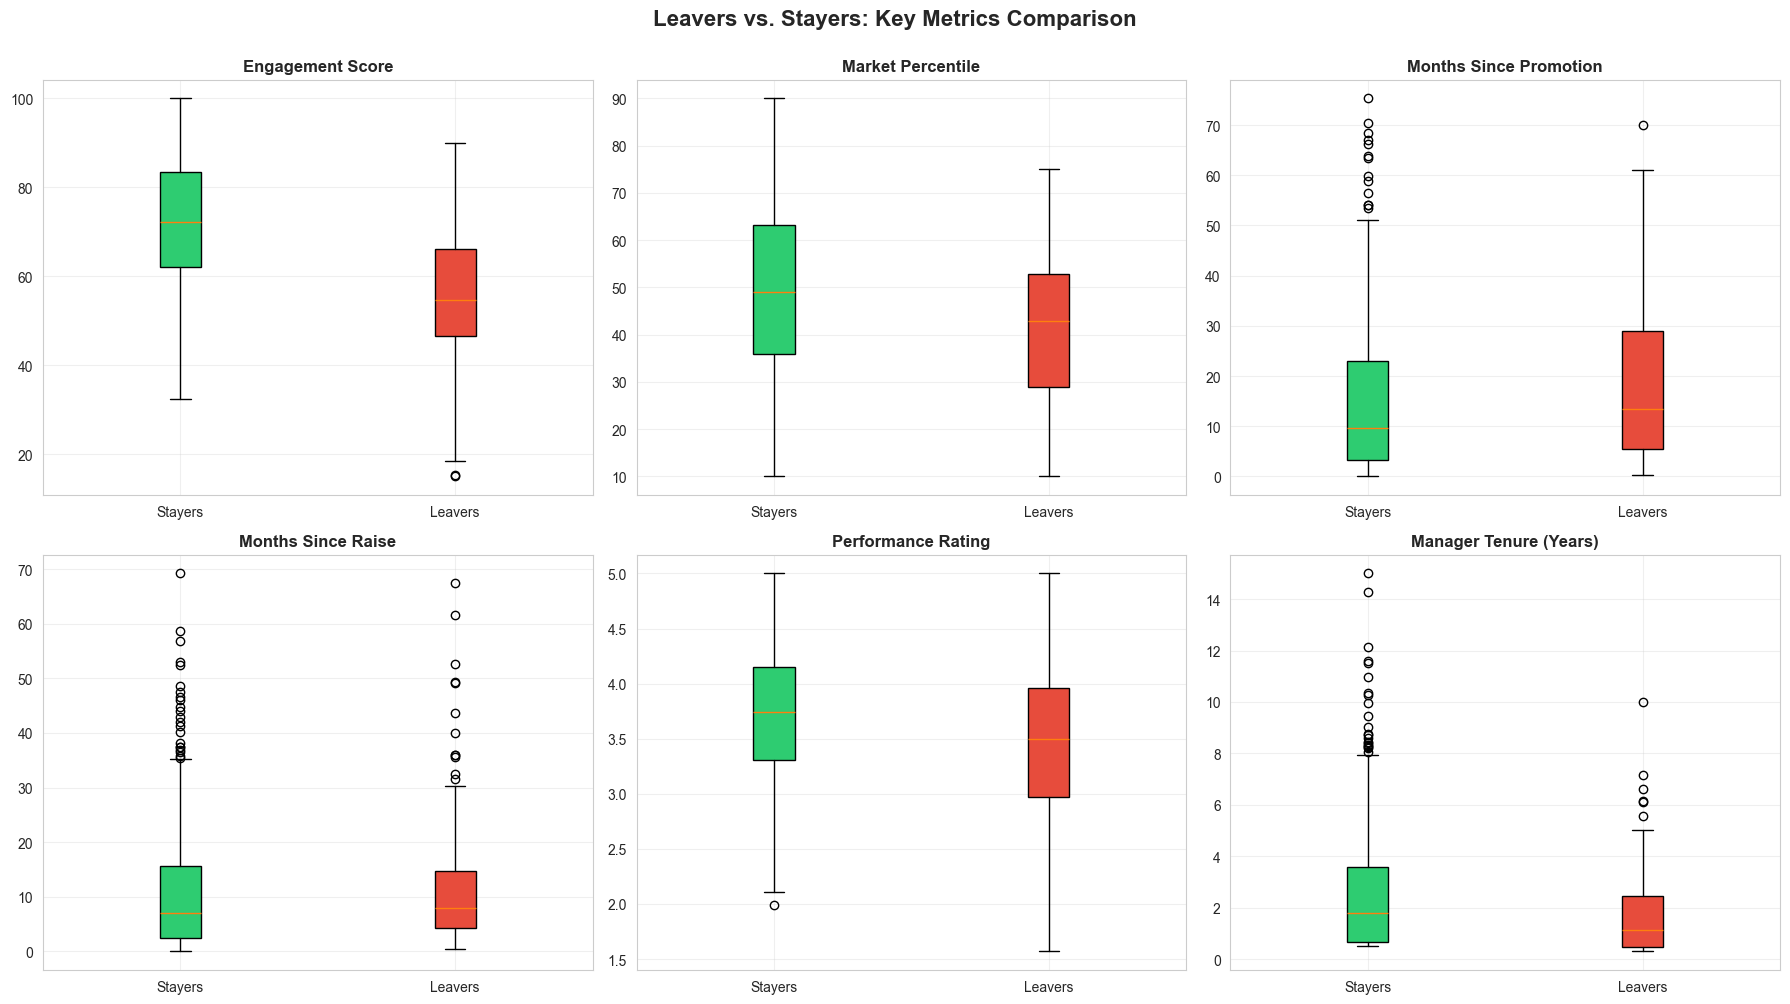

In [3]:
# Visualize key differences
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

metrics_to_plot = [
    ('engagement_score', 'Engagement Score'),
    ('market_percentile', 'Market Percentile'),
    ('months_since_promotion', 'Months Since Promotion'),
    ('months_since_raise', 'Months Since Raise'),
    ('performance_rating', 'Performance Rating'),
    ('manager_tenure_years', 'Manager Tenure (Years)')
]

for i, (metric, label) in enumerate(metrics_to_plot):
    data_to_plot = [stayers[metric].dropna(), leavers[metric].dropna()]
    bp = axes[i].boxplot(data_to_plot, labels=['Stayers', 'Leavers'], patch_artist=True)
    
    # Color boxes
    bp['boxes'][0].set_facecolor('#2ecc71')
    bp['boxes'][1].set_facecolor('#e74c3c')
    
    axes[i].set_title(label, fontsize=12, fontweight='bold')
    axes[i].grid(alpha=0.3)

plt.suptitle('Leavers vs. Stayers: Key Metrics Comparison', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## 2. Correlation Analysis

In [4]:
# Create binary target: departed (1) or stayed (0)
employees['departed'] = (employees['status'] == 'Terminated').astype(int)

# Calculate correlations with departure
correlation_metrics = [
    'engagement_score',
    'performance_rating',
    'market_percentile',
    'months_since_promotion',
    'months_since_raise',
    'manager_tenure_years',
    'tenure_years',
    'high_performer',
    'critical_role'
]

correlations = []
for metric in correlation_metrics:
    corr = employees[[metric, 'departed']].corr().iloc[0, 1]
    correlations.append({
        'Metric': metric,
        'Correlation': corr
    })

corr_df = pd.DataFrame(correlations).sort_values('Correlation', key=abs, ascending=False)

print("\nCORRELATION WITH ATTRITION")
print("="*60)
print("Negative correlation = Lower values associated with leaving")
print("Positive correlation = Higher values associated with leaving")
print("="*60)
for _, row in corr_df.iterrows():
    corr_val = row['Correlation']
    direction = "↑" if corr_val > 0 else "↓"
    print(f"{row['Metric']:30s} {direction} {corr_val:7.3f}")
print("="*60)


CORRELATION WITH ATTRITION
Negative correlation = Lower values associated with leaving
Positive correlation = Higher values associated with leaving
engagement_score               ↓  -0.447
market_percentile              ↓  -0.196
performance_rating             ↓  -0.177
tenure_years                   ↓  -0.176
manager_tenure_years           ↓  -0.154
high_performer                 ↓  -0.101
months_since_promotion         ↑   0.101
months_since_raise             ↑   0.057
critical_role                  ↑   0.020


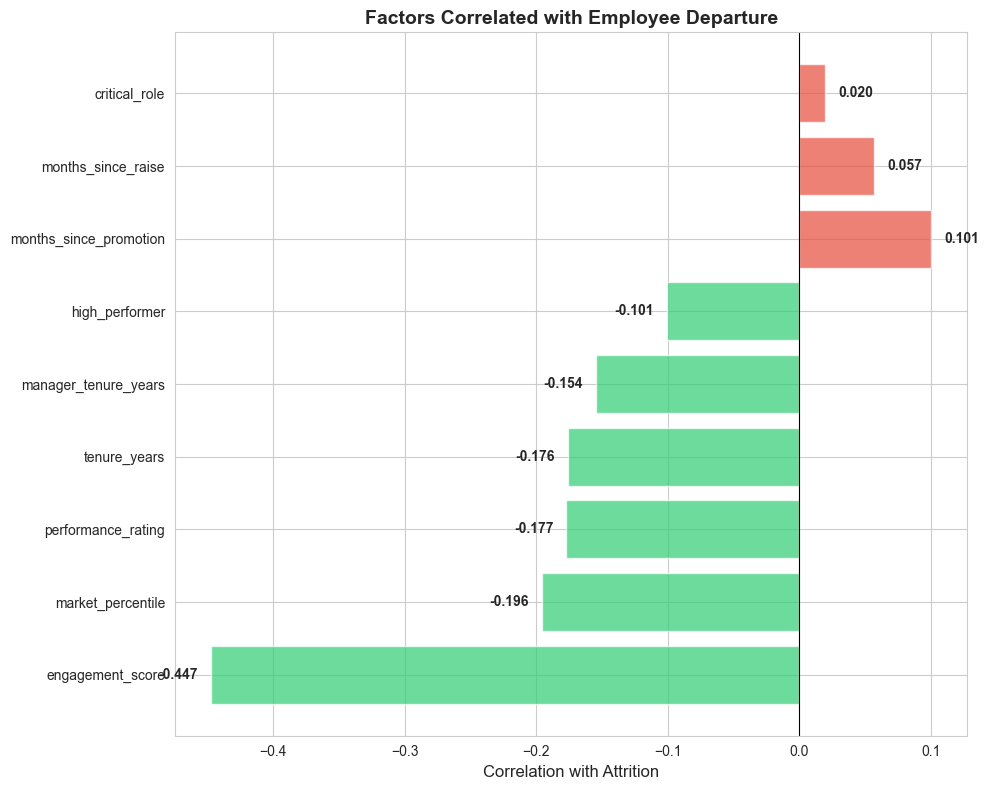

In [5]:
# Visualize correlations
fig, ax = plt.subplots(figsize=(10, 8))

colors = ['#e74c3c' if x > 0 else '#2ecc71' for x in corr_df['Correlation']]
bars = ax.barh(range(len(corr_df)), corr_df['Correlation'], color=colors, alpha=0.7)

ax.set_yticks(range(len(corr_df)))
ax.set_yticklabels(corr_df['Metric'])
ax.set_xlabel('Correlation with Attrition', fontsize=12)
ax.set_title('Factors Correlated with Employee Departure', fontsize=14, fontweight='bold')
ax.axvline(0, color='black', linewidth=0.8)

# Add value labels
for i, val in enumerate(corr_df['Correlation']):
    x_pos = val + (0.01 if val > 0 else -0.01)
    ha = 'left' if val > 0 else 'right'
    ax.text(x_pos, i, f'{val:.3f}', va='center', ha=ha, fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Exit Interview Analysis

In [6]:
# Analyze exit interviews
completed_exits = exit_interviews[exit_interviews['completed'] == 'Yes']

print("\nEXIT INTERVIEW ANALYSIS")
print("="*60)
print(f"Total departed employees: {len(leavers)}")
print(f"Exit interviews completed: {len(completed_exits)} ({len(completed_exits)/len(leavers)*100:.1f}%)")
print("="*60)

# Primary reasons for leaving
print("\nPRIMARY REASONS FOR LEAVING")
print("="*60)
reason_counts = completed_exits['primary_reason'].value_counts()
for reason, count in reason_counts.items():
    pct = (count / len(completed_exits)) * 100
    print(f"{reason:35s}: {count:3d} ({pct:5.1f}%)")
print("="*60)

# Satisfaction scores
print("\nAVERAGE SATISFACTION SCORES (1-5 scale)")
print("="*60)
satisfaction_metrics = [
    ('overall_satisfaction', 'Overall Satisfaction'),
    ('manager_satisfaction', 'Manager Satisfaction'),
    ('growth_satisfaction', 'Growth Opportunities'),
    ('compensation_satisfaction', 'Compensation'),
    ('worklife_satisfaction', 'Work-Life Balance')
]

for col, label in satisfaction_metrics:
    avg = completed_exits[col].mean()
    print(f"{label:25s}: {avg:.2f}")
print("="*60)

# Would rehire
rehire_counts = completed_exits['would_rehire'].value_counts()
print(f"\nWOULD REHIRE RATE: {rehire_counts.get('Yes', 0)} Yes, {rehire_counts.get('No', 0)} No")
if 'Yes' in rehire_counts:
    rehire_rate = rehire_counts['Yes'] / len(completed_exits) * 100
    print(f"  → {rehire_rate:.1f}% would be rehired (good indicator of positive departure)")


EXIT INTERVIEW ANALYSIS
Total departed employees: 150
Exit interviews completed: 102 (68.0%)

PRIMARY REASONS FOR LEAVING
Limited Growth Opportunities       :  21 ( 20.6%)
Compensation                       :  21 ( 20.6%)
Work-Life Balance                  :  17 ( 16.7%)
Manager Relationship               :  12 ( 11.8%)
Other                              :  12 ( 11.8%)
Better Opportunity                 :  10 (  9.8%)
Company Culture                    :   9 (  8.8%)

AVERAGE SATISFACTION SCORES (1-5 scale)
Overall Satisfaction     : 2.85
Manager Satisfaction     : 2.75
Growth Opportunities     : 2.38
Compensation             : 2.65
Work-Life Balance        : 2.98

WOULD REHIRE RATE: 27 Yes, 75 No
  → 26.5% would be rehired (good indicator of positive departure)


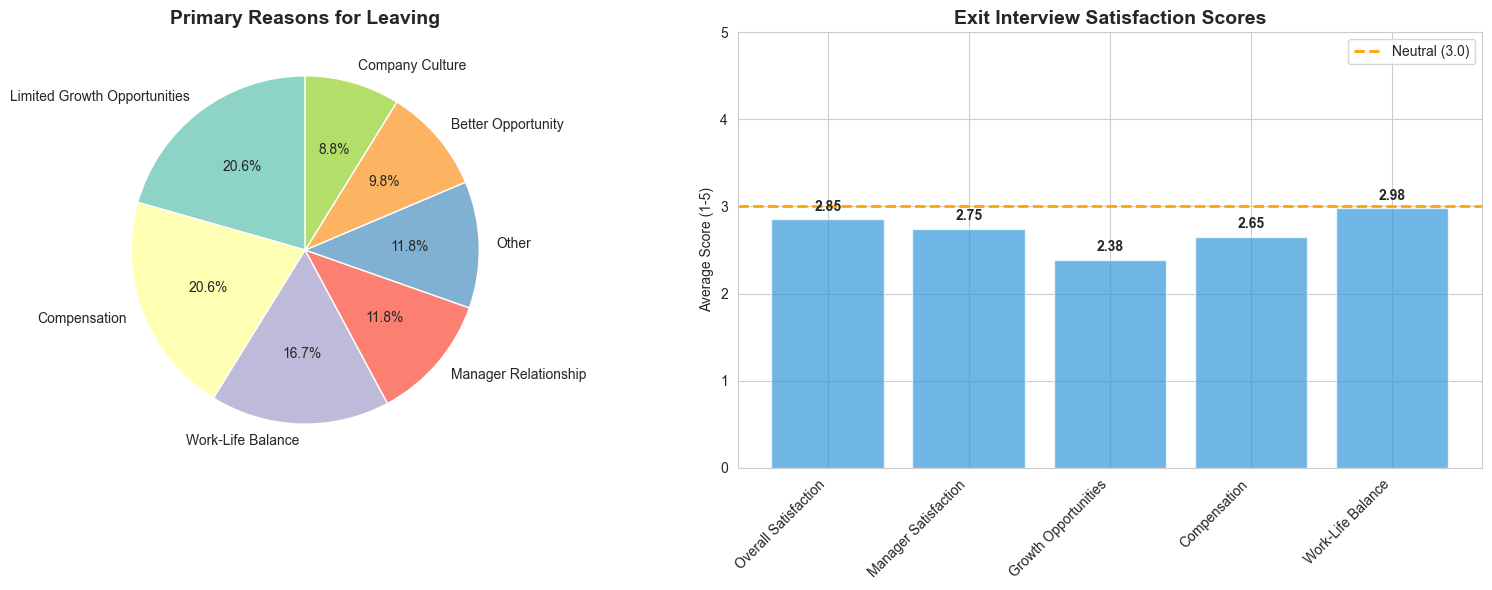

In [7]:
# Visualize exit interview insights
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Primary reasons pie chart
ax1.pie(reason_counts.values, labels=reason_counts.index, autopct='%1.1f%%',
        startangle=90, colors=plt.cm.Set3.colors)
ax1.set_title('Primary Reasons for Leaving', fontsize=14, fontweight='bold')

# Satisfaction scores bar chart
sat_labels = [label for _, label in satisfaction_metrics]
sat_values = [completed_exits[col].mean() for col, _ in satisfaction_metrics]

bars = ax2.bar(range(len(sat_labels)), sat_values, color='#3498db', alpha=0.7)
ax2.set_xticks(range(len(sat_labels)))
ax2.set_xticklabels(sat_labels, rotation=45, ha='right')
ax2.set_ylabel('Average Score (1-5)')
ax2.set_ylim(0, 5)
ax2.axhline(3.0, color='orange', linestyle='--', linewidth=2, label='Neutral (3.0)')
ax2.set_title('Exit Interview Satisfaction Scores', fontsize=14, fontweight='bold')
ax2.legend()

# Add value labels
for i, val in enumerate(sat_values):
    ax2.text(i, val + 0.1, f'{val:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Compensation Impact Analysis

In [8]:
# Analyze attrition by compensation percentile
def comp_bucket(percentile):
    if percentile < 25:
        return 'Bottom Quartile (<25%)'
    elif percentile < 50:
        return 'Below Median (25-50%)'
    elif percentile < 75:
        return 'Above Median (50-75%)'
    else:
        return 'Top Quartile (75%+)'

employees['comp_bucket'] = employees['market_percentile'].apply(comp_bucket)

comp_analysis = employees.groupby('comp_bucket').agg({
    'employee_id': 'count',
    'status': lambda x: (x == 'Terminated').sum()
}).rename(columns={'employee_id': 'total', 'status': 'departed'})

comp_analysis['attrition_rate'] = (comp_analysis['departed'] / comp_analysis['total'] * 100).round(1)

# Sort by logical order
comp_order = ['Bottom Quartile (<25%)', 'Below Median (25-50%)', 
              'Above Median (50-75%)', 'Top Quartile (75%+']
comp_analysis = comp_analysis.reindex(comp_order)

print("\nATTRITION RATE BY COMPENSATION LEVEL")
print("="*70)
print(comp_analysis)
print("="*70)

print("\nKEY INSIGHT:")
bottom_attrition = comp_analysis.loc['Bottom Quartile (<25%)', 'attrition_rate']
top_attrition = comp_analysis.loc['Top Quartile (75%+', 'attrition_rate']
diff = bottom_attrition - top_attrition

if diff > 10:
    print(f"⚠️  Employees in bottom compensation quartile have {diff:.1f}% higher attrition")
    print("   → Compensation competitiveness is a MAJOR retention driver")
    print("   → Consider market adjustments for underpaid employees")
else:
    print("ℹ️  Compensation shows modest impact on attrition")
    print("   → Other factors may be more important drivers")


ATTRITION RATE BY COMPENSATION LEVEL
                        total  departed  attrition_rate
comp_bucket                                            
Bottom Quartile (<25%)   77.0      29.0            37.7
Below Median (25-50%)   286.0      77.0            26.9
Above Median (50-75%)   222.0      39.0            17.6
Top Quartile (75%+        NaN       NaN             NaN

KEY INSIGHT:
ℹ️  Compensation shows modest impact on attrition
   → Other factors may be more important drivers


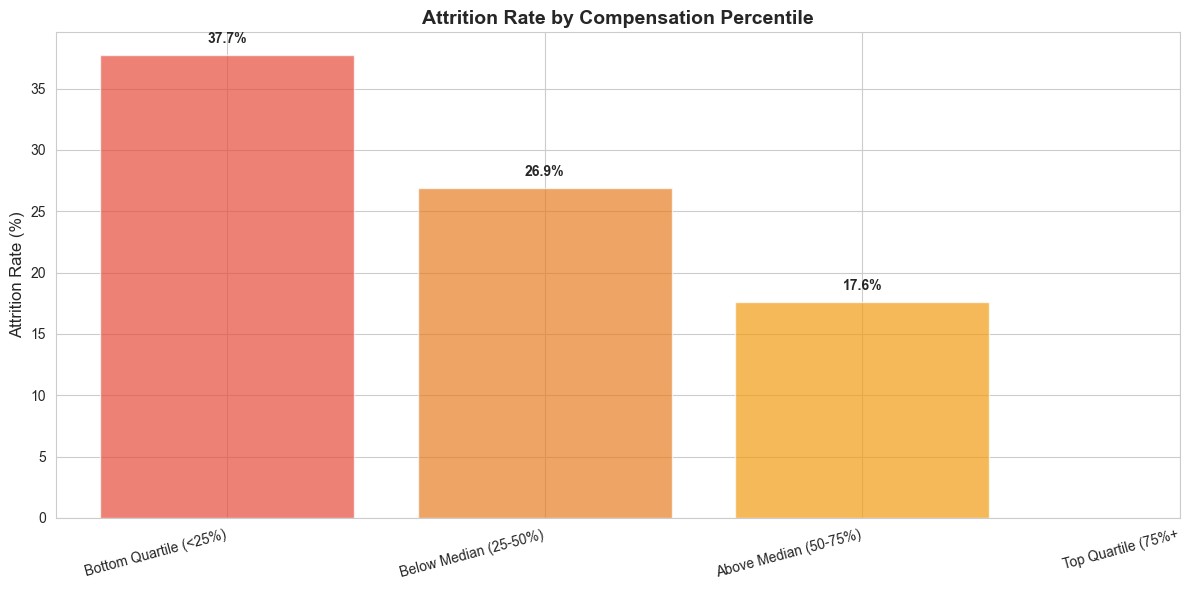

In [9]:
# Visualize compensation impact
fig, ax = plt.subplots(figsize=(12, 6))

x_pos = range(len(comp_analysis))
bars = ax.bar(x_pos, comp_analysis['attrition_rate'], 
              color=['#e74c3c', '#e67e22', '#f39c12', '#2ecc71'], alpha=0.7)

ax.set_xticks(x_pos)
ax.set_xticklabels(comp_analysis.index, rotation=15, ha='right')
ax.set_ylabel('Attrition Rate (%)', fontsize=12)
ax.set_title('Attrition Rate by Compensation Percentile', fontsize=14, fontweight='bold')

# Add value labels
for i, val in enumerate(comp_analysis['attrition_rate']):
    ax.text(i, val + 1, f'{val}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Promotion Velocity Impact

In [10]:
# Analyze impact of time since promotion
def promo_bucket(months):
    if months < 12:
        return '<1 year'
    elif months < 24:
        return '1-2 years'
    elif months < 36:
        return '2-3 years'
    else:
        return '3+ years'

employees['promo_bucket'] = employees['months_since_promotion'].apply(promo_bucket)

promo_analysis = employees.groupby('promo_bucket').agg({
    'employee_id': 'count',
    'status': lambda x: (x == 'Terminated').sum()
}).rename(columns={'employee_id': 'total', 'status': 'departed'})

promo_analysis['attrition_rate'] = (promo_analysis['departed'] / promo_analysis['total'] * 100).round(1)

promo_order = ['<1 year', '1-2 years', '2-3 years', '3+ years']
promo_analysis = promo_analysis.reindex(promo_order)

print("\nATTRITION RATE BY TIME SINCE LAST PROMOTION")
print("="*60)
print(promo_analysis)
print("="*60)

print("\nKEY INSIGHT:")
recent_promo = promo_analysis.loc['<1 year', 'attrition_rate']
stale_promo = promo_analysis.loc['3+ years', 'attrition_rate']
diff = stale_promo - recent_promo

if diff > 10:
    print(f"⚠️  Employees 3+ years without promotion have {diff:.1f}% higher attrition")
    print("   → Career growth is a CRITICAL retention driver")
    print("   → Review promotion pipeline and career pathing")
else:
    print("ℹ️  Time since promotion shows moderate impact")


ATTRITION RATE BY TIME SINCE LAST PROMOTION
              total  departed  attrition_rate
promo_bucket                                 
<1 year         342        67            19.6
1-2 years       138        36            26.1
2-3 years        87        20            23.0
3+ years         83        27            32.5

KEY INSIGHT:
⚠️  Employees 3+ years without promotion have 12.9% higher attrition
   → Career growth is a CRITICAL retention driver
   → Review promotion pipeline and career pathing


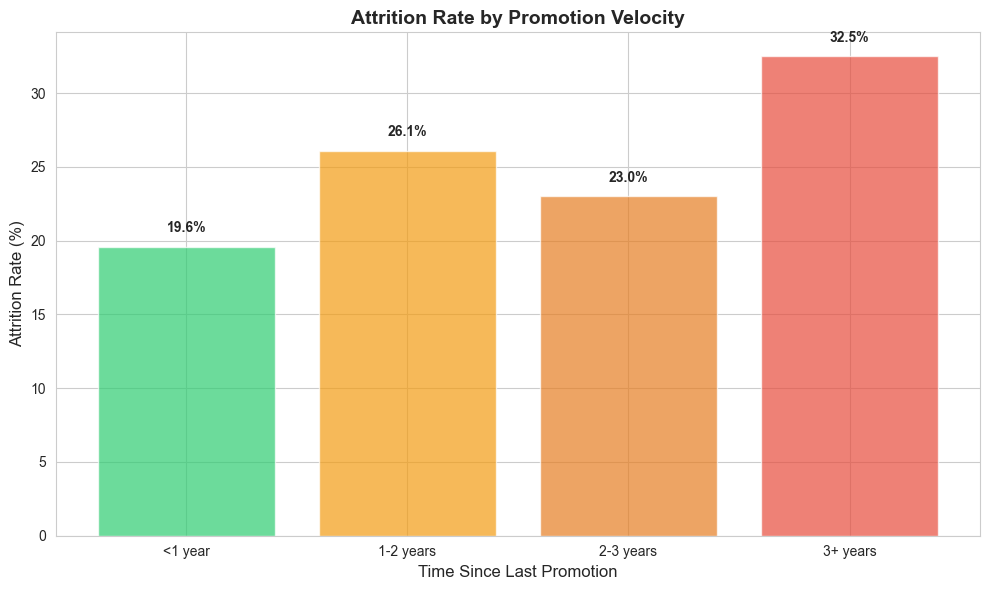

In [11]:
# Visualize promotion impact
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(range(len(promo_analysis)), promo_analysis['attrition_rate'],
              color=['#2ecc71', '#f39c12', '#e67e22', '#e74c3c'], alpha=0.7)

ax.set_xticks(range(len(promo_analysis)))
ax.set_xticklabels(promo_analysis.index)
ax.set_ylabel('Attrition Rate (%)', fontsize=12)
ax.set_xlabel('Time Since Last Promotion', fontsize=12)
ax.set_title('Attrition Rate by Promotion Velocity', fontsize=14, fontweight='bold')

# Add value labels
for i, val in enumerate(promo_analysis['attrition_rate']):
    ax.text(i, val + 1, f'{val}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 6. Engagement Impact on Retention

In [12]:
# Analyze engagement vs. attrition
def engagement_bucket(score):
    if score < 50:
        return 'Low (<50)'
    elif score < 70:
        return 'Medium (50-70)'
    else:
        return 'High (70+)'

employees['engagement_bucket'] = employees['engagement_score'].apply(engagement_bucket)

engagement_analysis = employees.groupby('engagement_bucket').agg({
    'employee_id': 'count',
    'status': lambda x: (x == 'Terminated').sum()
}).rename(columns={'employee_id': 'total', 'status': 'departed'})

engagement_analysis['attrition_rate'] = (engagement_analysis['departed'] / engagement_analysis['total'] * 100).round(1)

engagement_order = ['Low (<50)', 'Medium (50-70)', 'High (70+)']
engagement_analysis = engagement_analysis.reindex(engagement_order)

print("\nATTRITION RATE BY ENGAGEMENT LEVEL")
print("="*60)
print(engagement_analysis)
print("="*60)

print("\nKEY INSIGHT:")
low_engagement_attrition = engagement_analysis.loc['Low (<50)', 'attrition_rate']
high_engagement_attrition = engagement_analysis.loc['High (70+)', 'attrition_rate']
diff = low_engagement_attrition - high_engagement_attrition

if diff > 15:
    print(f"⚠️  Low engagement employees have {diff:.1f}% higher attrition!")
    print("   → Engagement is a STRONG predictor of attrition")
    print("   → Focus retention efforts on low-engagement populations")
else:
    print("ℹ️  Engagement shows moderate relationship with attrition")


ATTRITION RATE BY ENGAGEMENT LEVEL
                   total  departed  attrition_rate
engagement_bucket                                 
Low (<50)             92        54            58.7
Medium (50-70)       248        70            28.2
High (70+)           310        26             8.4

KEY INSIGHT:
⚠️  Low engagement employees have 50.3% higher attrition!
   → Engagement is a STRONG predictor of attrition
   → Focus retention efforts on low-engagement populations


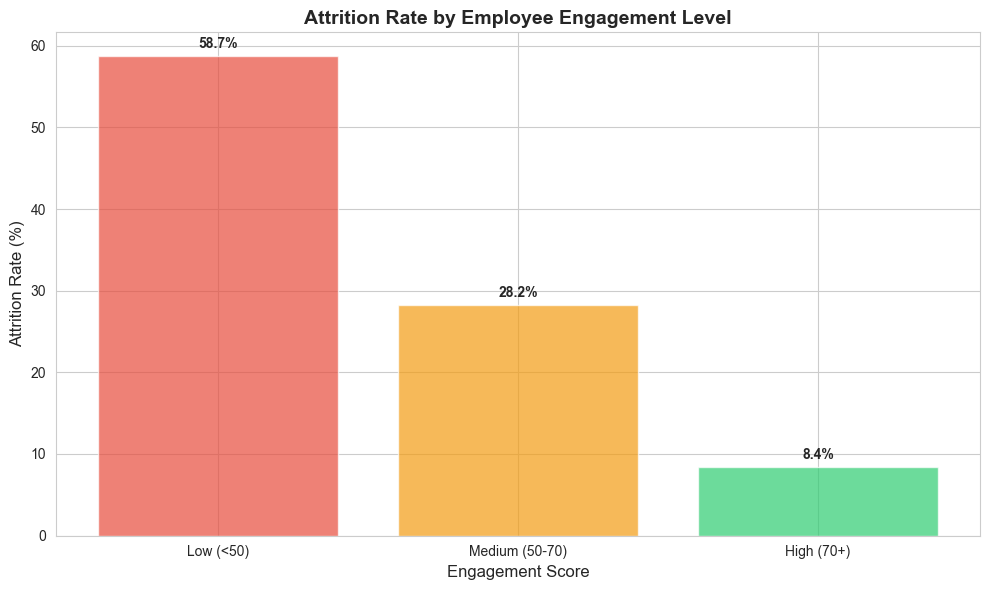

In [13]:
# Visualize engagement impact
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(range(len(engagement_analysis)), engagement_analysis['attrition_rate'],
              color=['#e74c3c', '#f39c12', '#2ecc71'], alpha=0.7)

ax.set_xticks(range(len(engagement_analysis)))
ax.set_xticklabels(engagement_analysis.index)
ax.set_ylabel('Attrition Rate (%)', fontsize=12)
ax.set_xlabel('Engagement Score', fontsize=12)
ax.set_title('Attrition Rate by Employee Engagement Level', fontsize=14, fontweight='bold')

# Add value labels
for i, val in enumerate(engagement_analysis['attrition_rate']):
    ax.text(i, val + 1, f'{val}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 7. Summary: Top Retention Drivers

In [14]:
print("\n" + "="*80)
print("TOP RETENTION DRIVERS (Ranked by Impact)")
print("="*80)

# Compile all findings
drivers = []

# Engagement
if 'diff' in locals():
    eng_diff = low_engagement_attrition - high_engagement_attrition
    drivers.append(('Engagement', eng_diff, 
                   'Low engagement (<50) employees have much higher attrition'))

# Compensation
comp_diff = bottom_attrition - top_attrition
drivers.append(('Compensation Competitiveness', comp_diff,
               'Bottom quartile comp employees are at higher risk'))

# Promotion velocity
promo_diff = stale_promo - recent_promo
drivers.append(('Career Growth / Promotion Velocity', promo_diff,
               '3+ years without promotion increases attrition'))

# Sort by impact
drivers.sort(key=lambda x: x[1], reverse=True)

for i, (driver, impact, description) in enumerate(drivers, 1):
    print(f"\n{i}. {driver.upper()}")
    print(f"   Impact: {impact:.1f} percentage point difference in attrition")
    print(f"   Finding: {description}")

# Exit interview top reason
top_exit_reason = reason_counts.index[0]
print(f"\n4. PRIMARY DEPARTURE REASON (from exit interviews)")
print(f"   Most common: {top_exit_reason}")
print(f"   {reason_counts.iloc[0]} of {len(completed_exits)} exit interviews cited this")

print("\n" + "="*80)


TOP RETENTION DRIVERS (Ranked by Impact)

1. ENGAGEMENT
   Impact: 50.3 percentage point difference in attrition
   Finding: Low engagement (<50) employees have much higher attrition

2. COMPENSATION COMPETITIVENESS
   Impact: nan percentage point difference in attrition
   Finding: Bottom quartile comp employees are at higher risk

3. CAREER GROWTH / PROMOTION VELOCITY
   Impact: 12.9 percentage point difference in attrition
   Finding: 3+ years without promotion increases attrition

4. PRIMARY DEPARTURE REASON (from exit interviews)
   Most common: Limited Growth Opportunities
   21 of 102 exit interviews cited this



## 8. Recommended Actions

In [15]:
print("\n" + "="*80)
print("RECOMMENDED RETENTION INTERVENTIONS")
print("="*80)

print("\n1. ENGAGEMENT-FOCUSED INTERVENTIONS")
low_engagement_count = len(employees[(employees['status']=='Active') & (employees['engagement_score']<50)])
print(f"   Target: {low_engagement_count} active employees with engagement < 50")
print("   Actions:")
print("   → Conduct pulse surveys to understand disengagement drivers")
print("   → Manager training on engagement and retention conversations")
print("   → Team-building and recognition programs")

print("\n2. COMPENSATION EQUITY REVIEWS")
underpaid_count = len(employees[(employees['status']=='Active') & (employees['market_percentile']<25)])
print(f"   Target: {underpaid_count} active employees in bottom compensation quartile")
print("   Actions:")
print("   → Conduct market benchmarking study")
print("   → Prioritize adjustments for high performers below market")
print("   → Annual compensation review process")

print("\n3. CAREER DEVELOPMENT PROGRAMS")
stale_promo_count = len(employees[(employees['status']=='Active') & (employees['months_since_promotion']>=36)])
print(f"   Target: {stale_promo_count} active employees with 3+ years since promotion")
print("   Actions:")
print("   → Career pathing workshops and development plans")
print("   → Review promotion criteria and timeline expectations")
print("   → Lateral moves and skill development opportunities")

print(f"\n4. ADDRESS TOP EXIT REASON: {top_exit_reason.upper()}")
print("   Actions:")
if 'Compensation' in top_exit_reason:
    print("   → See compensation equity recommendations above")
    print("   → Consider retention bonuses for critical roles")
elif 'Growth' in top_exit_reason:
    print("   → See career development recommendations above")
    print("   → Create clear promotion pathways")
elif 'Manager' in top_exit_reason:
    print("   → Manager effectiveness training")
    print("   → 360 reviews for people managers")
    print("   → Manager attrition benchmarking")
else:
    print("   → Conduct deeper investigation into this reason")
    print("   → Design targeted interventions")

print("\n5. STAY INTERVIEW PROGRAM")
print("   Target: High performers and critical roles")
print("   Actions:")
print("   → Quarterly stay interviews with at-risk high performers")
print("   → Proactive retention planning vs. reactive exit interviews")

print("\n" + "="*80)
print("For predictive modeling to identify at-risk employees,")
print("see '02_flight_risk_prediction.ipynb'")
print("="*80)


RECOMMENDED RETENTION INTERVENTIONS

1. ENGAGEMENT-FOCUSED INTERVENTIONS
   Target: 38 active employees with engagement < 50
   Actions:
   → Conduct pulse surveys to understand disengagement drivers
   → Manager training on engagement and retention conversations
   → Team-building and recognition programs

2. COMPENSATION EQUITY REVIEWS
   Target: 48 active employees in bottom compensation quartile
   Actions:
   → Conduct market benchmarking study
   → Prioritize adjustments for high performers below market
   → Annual compensation review process

3. CAREER DEVELOPMENT PROGRAMS
   Target: 56 active employees with 3+ years since promotion
   Actions:
   → Career pathing workshops and development plans
   → Review promotion criteria and timeline expectations
   → Lateral moves and skill development opportunities

4. ADDRESS TOP EXIT REASON: LIMITED GROWTH OPPORTUNITIES
   Actions:
   → See career development recommendations above
   → Create clear promotion pathways

5. STAY INTERVIEW